<a href="https://colab.research.google.com/github/Gh4n5kH/mugni-data-science-2024/blob/main/Pertemuan11_Mugni_240401010355.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Muhamad Mugni Abdul Gani**

**NIM: 240401010355**

**Kelas: IF405**

==============================

**Langkah 1: Generate & Eksplorasi Dataset**

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


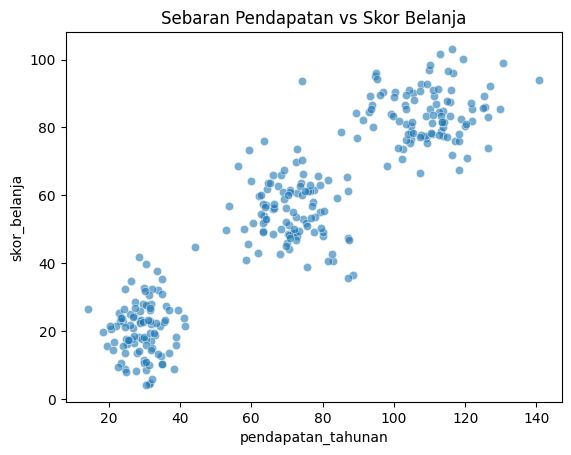

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])

df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print("Shape:", df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df,
                x='pendapatan_tahunan',
                y='skor_belanja',
                alpha=0.6)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

**Langkah 2: Preprocessing Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur numerik
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menampilkan hasil
print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


**Langkah 3: Metode Elbow untuk Menentukan K**

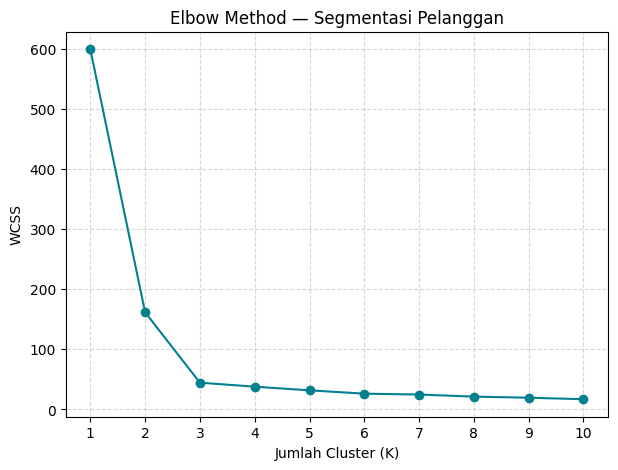

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.xticks(range(1,11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Interpretasi Elbow Method
* Berdasarkan grafik Elbow, kurva mulai melandai pada K = 3. Titik tersebut menunjukkan bahwa penambahan jumlah cluster setelah K = 3 hanya memberikan penurunan WCSS yang relatif kecil.
* Hasil ini sesuai dengan jumlah kelompok yang diharapkan, karena dataset sintetis memang dibuat dari tiga kelompok pelanggan, yaitu:
1. Pelanggan hemat
2. Pelanggan menengah
3. Pelanggan boros
* Oleh karena itu, jumlah cluster yang paling optimal untuk proses segmentasi pelanggan adalah K = 3, karena mampu merepresentasikan struktur data dengan baik tanpa menambah kompleksitas model secara berlebihan.

# Kesimpulan
* Titik elbow berada di K = 3.
* Jumlah cluster optimal adalah 3.
* Hasil sesuai dengan struktur dataset yang memang dibangun dari tiga kelompok pelanggan.

**Langkah 4: Melatih Model K-Means**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Melatih model K-Means dengan K = 3
model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)

# Menyimpan label cluster ke dataframe
df['cluster'] = model.labels_

# Evaluasi model
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}')

# Rata-rata setiap cluster
print(df.groupby('cluster')[['pendapatan_tahunan',
                             'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score : 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


**Langkah 5: Visualisasi Hasil Clustering**

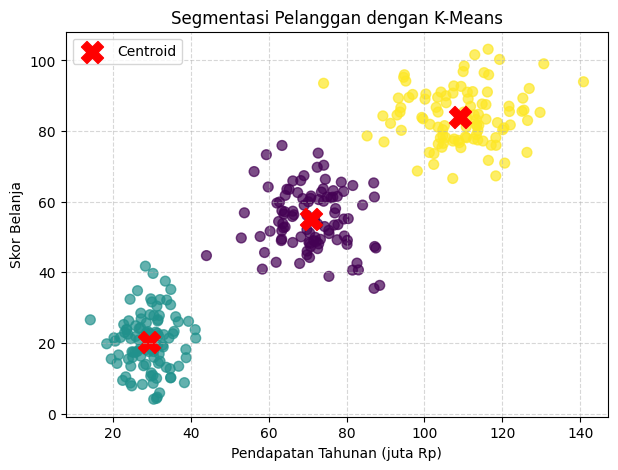

In [ ]:
import matplotlib.pyplot as plt

# Mengembalikan centroid ke skala asli
centroids = scaler.inverse_transform(model.cluster_centers_)

# Scatter plot hasil clustering
plt.figure(figsize=(7,5))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7,
    s=50
)

# Menampilkan centroid
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=250,
    label='Centroid'
)

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Langkah 6: Hierarchical Clustering (Pembanding)**

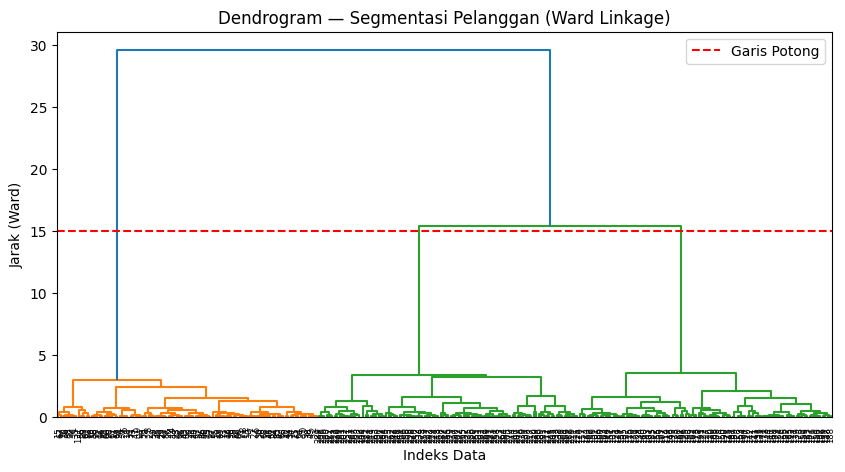

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Membuat linkage matrix dengan metode Ward
Z = linkage(X_scaled, method='ward')

# Menampilkan dendrogram
plt.figure(figsize=(10,5))

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=6
)

plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')

# Garis potong (contoh)
plt.axhline(y=15, color='red', linestyle='--', label='Garis Potong')

plt.legend()
plt.show()

1. Analisis Jumlah Cluster dari Dendrogram:
   - Garis potong pada y = 15 memotong 3 cabang utama sehingga terbentuk 3 cluster.

2. Apakah Konsisten dengan Metode Elbow?
   - JAWABAN: YA.
   - Metode Elbow menunjukkan jumlah cluster optimal pada K = 3, dan Dendrogram Ward Linkage juga menghasilkan 3 cluster.
   - Kedua metode memberikan hasil yang sama sehingga jumlah cluster optimal dinyatakan valid.

Kesimpulan:
   - Jumlah cluster terbaik adalah 3.
   - Hasil ini sesuai dengan struktur dataset yang terdiri atas tiga kelompok pelanggan: hemat, menengah, dan boros/premium.